# MLMarker Tissue Similarity — Cell Line NCI-H1650


In [ ]:
%pip install mlmarker
%pip install --upgrade openpyxl --force-reinstall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from mlmarker import MLMarker

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## 1. Configuration

In [2]:
# --- Sample / experiment identifiers -----------------------------------------
cmb = "CMB-2216"
baseline = "P0"
passage = "P11"

# --- Model output size ---------------------------------------------------------

N_TISSUES = 34

# --- SHAP driver settings -------------------------------------------------------

N_SHAP_DRIVERS_EACH = 20

# Data paths 
PROTEIN_INTENSITY_PATH = (
    "C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/"
    "Scripts data analyse/Datasets/results/CMB-2216/Protein_Intensities_Wide.csv"
)
DEA_DIR = (
    f"C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/Scripts data analyse/"
    f"Datasets/results/{cmb}/{passage}_vs_{baseline}/dea_lists"
)

## 2. Load & scale protein data

In [3]:
df = pd.read_csv(PROTEIN_INTENSITY_PATH, index_col=0)

print(df.index[:5])
print(df.shape)

Index(['1_1', '1_2', '1_3', '2_1', '2_2'], dtype='object')
(36, 4753)


In [4]:
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df.T).T,
    columns=df.columns,
    index=df.index,
)

## 3. Run MLMarker per sample

For every sample this now stores:
- **every** tissue prediction (up to `N_TISSUES`), so we can build the full
  ranked table
- the SHAP dataframe (`shap_results`), pulled with the same `N_TISSUES` so that whichever
  tissue ends up on top (e.g. B-cell) is guaranteed to be explainable

In [5]:
model = MLMarker(binary=False, penalty_factor=1)

prediction_records = []   # long-format: one row per (sample, rank/tissue)
shap_results = {}         # sample_id -> full SHAP dataframe (tissues x proteins)

for sample_name, protein_data in df_scaled.iterrows():
    sample_df = pd.DataFrame(protein_data).T

    try:
        # Parse passage number and replicate ID (assumes naming like '1_1')
        sample_parts = str(sample_name).split("_")
        raw_passage = int(sample_parts[0])
        passage_num = raw_passage - 1
        replicate_id = sample_parts[1] if len(sample_parts) > 1 else "1"

        model.load_sample(sample_df)
        predictions = model.predict_top_tissues_shap(n_preds=N_TISSUES)

        # Store every tissue prediction with its rank
        for rank, (tissue, prob) in enumerate(predictions, start=1):
            prediction_records.append(
                {
                    "Sample": sample_name,
                    "Passage": passage_num,
                    "Replicate": f"Rep {replicate_id}",
                    "Rank": rank,
                    "Tissue": tissue.strip(),
                    "Probability": prob,
                }
            )

        print(f"Processing: {sample_name} (Passage {passage_num}, Rep {replicate_id})")

        # Pull SHAP values across the same number of tissues so the top-predicted
        # tissue (e.g. B-cell) is always included, not just Lung
        shap_df = model.explainability.get_shap_values(n_preds=N_TISSUES)
        shap_results[sample_name] = shap_df

    except Exception as e:
        print(f"Error processing sample {sample_name}: {e}")

df_predictions_long = pd.DataFrame(prediction_records).sort_values(
    ["Passage", "Replicate", "Rank"]
).reset_index(drop=True)

df_predictions_long.head(N_TISSUES)

Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 1_1 (Passage 0, Rep 1)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 1_2 (Passage 0, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


...

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 12_2 (Passage 11, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 12_3 (Passage 11, Rep 3)


,Sample,Passage,Replicate,Rank,Tissue,Probability
0,1_1,0,Rep 1,1,B-cells,0.2351
1,1_1,0,Rep 1,2,Parotid gland,0.1226
2,1_1,0,Rep 1,3,Testis,0.0841
3,1_1,0,Rep 1,4,Tonsil,0.0676
4,1_1,0,Rep 1,5,Skeletal muscle,0.0601
5,1_1,0,Rep 1,6,Pituitary gland,0.0524
6,1_1,0,Rep 1,7,Nasal Polyps,0.0422
7,1_1,0,Rep 1,8,Placenta,0.0363
8,1_1,0,Rep 1,9,Ovary,0.0347
9,1_1,0,Rep 1,10,Kidney,0.0346


## 4. Clear top-34 prediction table

Two views:
- **Wide table**: one row per sample, one column per tissue, values = predicted probability
  (rank order preserved by mean probability across samples).
- **Rank summary**: for each sample, the #1 predicted tissue and where Lung specifically
  ranks 


In [6]:
# Wide table: Sample x Tissue probability matrix, ordered by average probability
df_predictions_wide = df_predictions_long.pivot_table(
    index="Sample", columns="Tissue", values="Probability"
)
tissue_order = df_predictions_wide.mean(axis=0).sort_values(ascending=False).index
df_predictions_wide = df_predictions_wide[tissue_order]

df_predictions_wide

Tissue,B-cells,Parotid gland,Testis,Tonsil,Skeletal muscle,Pituitary gland,Placenta,Nasal Polyps,Salivary gland,Ovary,...,Stomach,Monocytes,Endometrium,Adipose tissue,Lymph node,Thyroid,Spleen,Smooth muscle,Lung,Bone marrow
Sample,,,,,,,,,,,,,,,,,,,,,
10_1,0.2095,0.1296,0.0877,0.0685,0.0665,0.0471,0.0334,0.0420,0.0365,0.0409,...,0.0066,-0.0020,0.0074,0.0021,0.0014,0.0058,-0.0060,-0.0081,-0.0073,-0.0891
10_2,0.2089,0.1294,0.0850,0.0674,0.0654,0.0517,0.0381,0.0420,0.0367,0.0411,...,0.0099,0.0010,0.0074,0.0040,0.0015,0.0045,-0.0067,-0.0082,-0.0052,-0.0875
10_3,0.2144,0.0939,0.1032,0.0680,0.0607,0.0567,0.0428,0.0418,0.0373,0.0483,...,0.0079,0.0112,0.0101,0.0031,0.0026,0.0040,-0.0129,-0.0057,-0.0062,-0.0870
11_1,0.2247,0.1239,0.0901,0.0675,0.0598,0.0460,0.0435,0.0421,0.0386,0.0329,...,0.0118,0.0064,0.0072,0.0043,0.0012,0.0026,-0.0068,-0.0087,-0.0152,-0.0962
11_2,0.2095,0.1294,0.0849,0.0732,0.0657,0.0520,0.0451,0.0418,0.0415,0.0373,...,0.0119,0.0071,0.0074,0.0098,0.0012,-0.0007,-0.0065,-0.0079,-0.0099,-0.0976
11_3,0.2293,0.1087,0.0905,0.0679,0.0607,0.0560,0.0435,0.0414,0.0365,0.0371,...,0.0107,0.0076,0.0066,0.0047,0.0010,-0.0018,-0.0062,-0.0083,-0.0120,-0.0935
12_1,0.2252,0.1244,0.0907,0.0677,0.0662,0.0572,0.0483,0.0421,0.0364,0.0321,...,0.0108,0.0071,0.0078,0.0023,0.0012,0.0046,-0.0026,-0.0076,-0.0107,-0.0998
12_2,0.2244,0.1240,0.0981,0.0675,0.0650,0.0520,0.0430,0.0421,0.0368,0.0322,...,0.0120,0.0056,0.0077,0.0049,0.0019,-0.0008,-0.0070,-0.0082,-0.0121,-0.1060
12_3,0.2001,0.1193,0.1167,0.0676,0.0658,0.0489,0.0432,0.0422,0.0366,0.0321,...,0.0133,0.0128,0.0070,0.0018,0.0092,0.0021,-0.0075,-0.0082,-0.0062,-0.0940


In [7]:
# Rank summary: top predicted tissue + Lung's specific rank/probability, per sample
top1 = (
    df_predictions_long[df_predictions_long["Rank"] == 1]
    .rename(columns={"Tissue": "Top1_Tissue", "Probability": "Top1_Probability"})
    [["Sample", "Passage", "Replicate", "Top1_Tissue", "Top1_Probability"]]
)

lung_rows = (
    df_predictions_long[df_predictions_long["Tissue"].str.lower() == "lung"]
    .rename(columns={"Rank": "Lung_Rank", "Probability": "Lung_Probability"})
    [["Sample", "Lung_Rank", "Lung_Probability"]]
)

df_rank_summary = top1.merge(lung_rows, on="Sample", how="left").sort_values(
    ["Passage", "Replicate"]
).reset_index(drop=True)

df_rank_summary

,Sample,Passage,Replicate,Top1_Tissue,Top1_Probability,Lung_Rank,Lung_Probability
0,1_1,0,Rep 1,B-cells,0.2023,33,-0.0175
1,1_2,0,Rep 2,B-cells,0.2166,33,-0.0171
2,1_3,0,Rep 3,B-cells,0.2162,33,-0.0244
3,2_1,1,Rep 1,B-cells,0.2299,32,-0.0083
4,2_2,1,Rep 2,B-cells,0.2299,33,-0.0091
5,2_3,1,Rep 3,B-cells,0.2304,33,-0.0095
6,3_1,2,Rep 1,B-cells,0.1938,33,-0.0144
7,3_2,2,Rep 2,B-cells,0.2041,33,-0.0158
8,3_3,2,Rep 3,B-cells,0.2244,33,-0.0126
9,4_1,3,Rep 1,B-cells,0.2415,33,-0.0113


## 5. Lung probability across passages (trend plot)

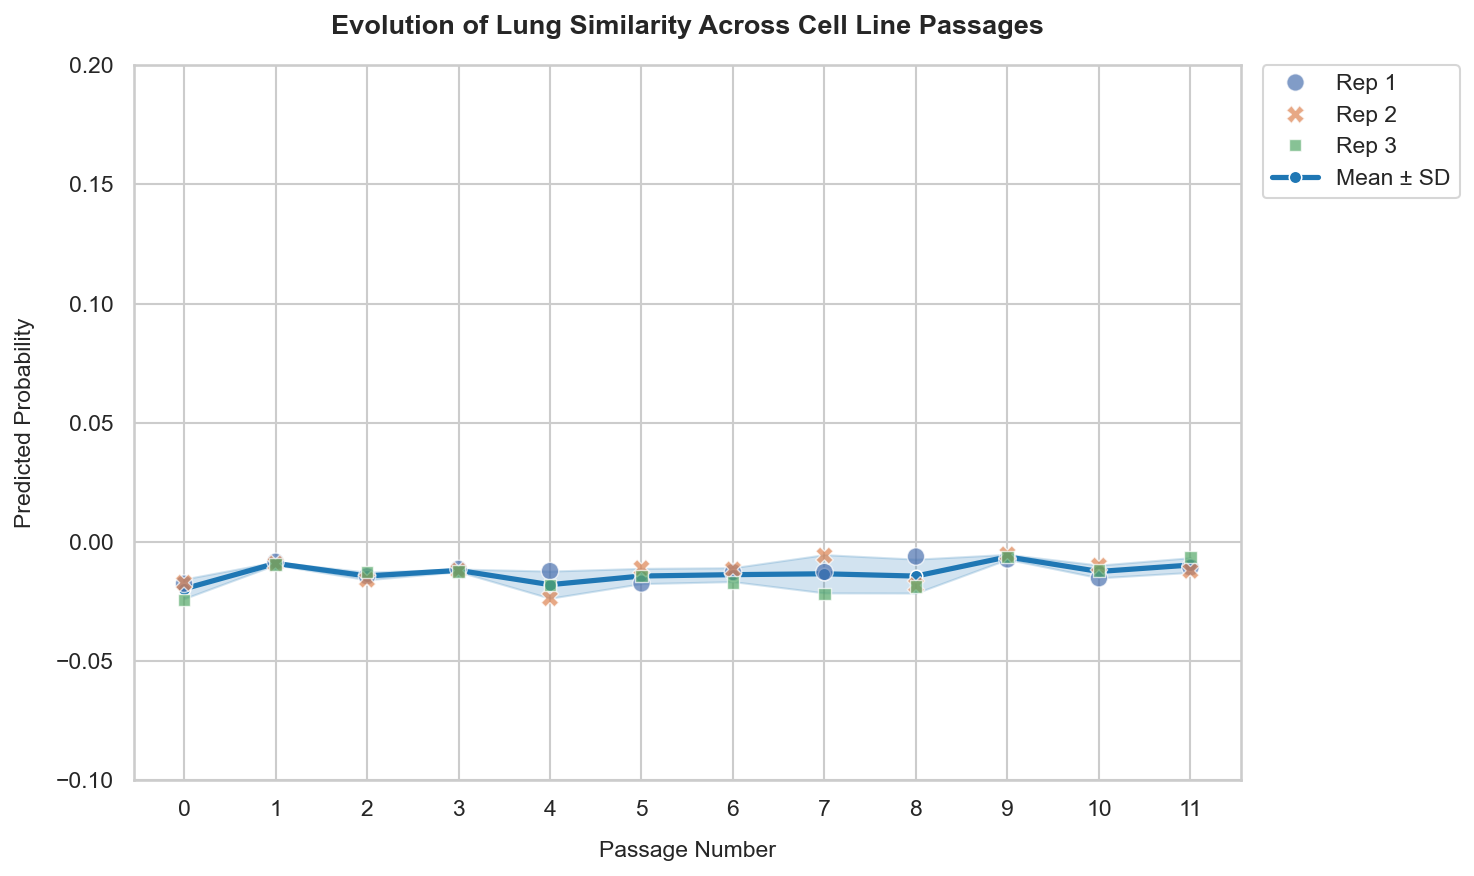

In [8]:
df_lung = df_predictions_long[df_predictions_long["Tissue"].str.lower() == "lung"].copy()

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_lung, x="Passage", y="Probability", hue="Replicate", style="Replicate",
    s=70, alpha=0.7, zorder=3,
)
sns.lineplot(
    data=df_lung, x="Passage", y="Probability", color="#1f77b4", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, label="Mean ± SD", zorder=2,
)

plt.title("Evolution of Lung Similarity Across Cell Line Passages", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Predicted Probability", fontsize=11, labelpad=10)
plt.xticks(df_lung["Passage"].unique().astype(int))

# Custom y-axis ticks: -1.5 to 0.2 in steps of 0.05
plt.ylim(-0.1, 0.2)
plt.yticks(np.arange(-0.1, 0.2 + 0.05, 0.05))

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

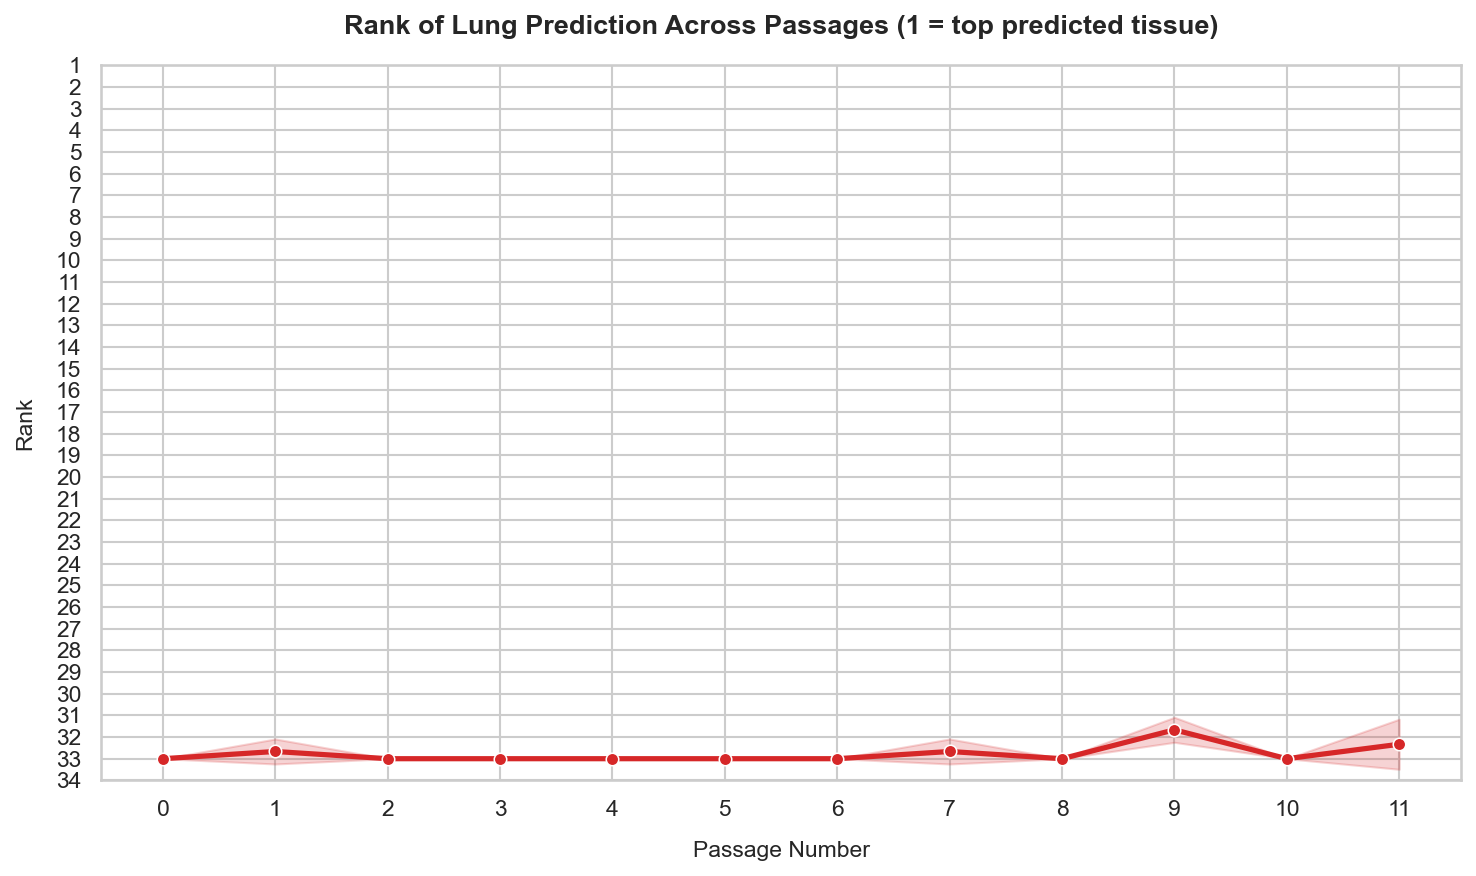

In [9]:
# Companion plot: Lung's RANK (1 = top prediction) across passages.
# This makes it obvious when/if another tissue (e.g. B-cell) overtakes Lung.
plt.figure(figsize=(10, 6), dpi=150)
sns.lineplot(
    data=df_lung, x="Passage", y="Rank", color="#d62728", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, zorder=2,
)

plt.ylim(1, 34)
plt.yticks(np.arange(1, 35, 1))  # 1, 2, 3, ..., 34
plt.gca().invert_yaxis()  # rank 1 at the top

plt.title("Rank of Lung Prediction Across Passages (1 = top predicted tissue)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Rank", fontsize=11, labelpad=10)
plt.xticks(df_lung["Passage"].unique().astype(int))
plt.tight_layout()
plt.show()

## 6. SHAP driver extraction


In [10]:
def get_top_bottom_shap(shap_results, tissue, n=N_SHAP_DRIVERS_EACH):
    """
    For each sample's SHAP dataframe, pull the n most negative and n most
    positive SHAP values for the given tissue row, and combine into one
    long-format summary dataframe.
    """
    summary_list = []

    for sample_id, df in shap_results.items():
        if tissue not in df.index:
            continue

        tissue_values = df.loc[tissue].sort_values()

        lowest_n = tissue_values.head(n)
        highest_n = tissue_values.tail(n)

        combined = pd.concat([lowest_n, highest_n])
        combined = combined[~combined.index.duplicated(keep="first")]

        sample_str = str(sample_id)
        parts = sample_str.split("_")

        raw_passage = int(parts[0])
        passage_num = raw_passage - 1
        replicate_id = int(parts[1]) if len(parts) > 1 else 1

        sample_summary = combined.to_frame(name="SHAP_Value")
        sample_summary["Sample_ID"] = sample_str
        sample_summary["Passage"] = passage_num
        sample_summary["Replicate"] = replicate_id
        sample_summary["Protein"] = sample_summary.index
        sample_summary["Tissue"] = tissue

        summary_list.append(sample_summary)

    if not summary_list:
        print(f"No data found for tissue '{tissue}'.")
        return pd.DataFrame()

    result_df = pd.concat(summary_list).reset_index(drop=True)
    result_df = result_df.sort_values(by=["Passage", "Replicate"]).reset_index(drop=True)
    result_df = result_df[["Sample_ID", "Passage", "Replicate", "Protein", "Tissue", "SHAP_Value"]]
    return result_df


# Lung drivers
final_summary_df = get_top_bottom_shap(shap_results, "Lung")
final_summary_df

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,1_1,0,1,P17661,Lung,-0.00389
1,1_1,0,1,P07476,Lung,-0.00280
2,1_1,0,1,Q14315,Lung,-0.00231
3,1_1,0,1,P02538,Lung,-0.00178
4,1_1,0,1,P35573,Lung,-0.00178
...,...,...,...,...,...,...
1435,12_3,11,3,Q13753,Lung,0.00217
1436,12_3,11,3,Q9HBH5,Lung,0.00236
1437,12_3,11,3,A6NMZ7,Lung,0.00269
1438,12_3,11,3,P48163,Lung,0.00348


In [11]:
# B-cell drivers, same structure as Lung
bcell_tissue_label = "B-cells"

final_summary_df_bcells = get_top_bottom_shap(shap_results, bcell_tissue_label)
final_summary_df_bcells

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,1_1,0,1,P09543,B-cells,-0.00692
1,1_1,0,1,Q9Y678,B-cells,-0.00666
2,1_1,0,1,P02585,B-cells,-0.00455
3,1_1,0,1,P54886,B-cells,-0.00325
4,1_1,0,1,O43149,B-cells,-0.00324
...,...,...,...,...,...,...
1435,12_3,11,3,Q9UQE7,B-cells,0.01278
1436,12_3,11,3,Q96SB8,B-cells,0.01384
1437,12_3,11,3,A6NHR9,B-cells,0.01445
1438,12_3,11,3,Q8TEM1,B-cells,0.01681
